In [1]:
import pandas as pd
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [4]:
df = pd.read_csv("Admission_Predict.csv")

In [5]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [7]:
df.shape

(400, 9)

In [8]:
df.drop(columns=['Serial No.'], inplace = True)

In [9]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [13]:
x = df.iloc[:, 0:-1]
y = df.iloc[:,-1]

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=.1)

In [16]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

In [17]:
x_train = mms.fit_transform(x_train)
x_test = mms.transform(x_test)

In [43]:
model = Sequential()

model.add(Dense(7, activation='relu', input_shape=(7,)))
model.add(Dense(7, activation='relu'))
model.add(Dense(1, activation='linear'))

c:\Users\ABDULLAH AL MASUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [46]:
history = model.fit(x_train, y_train, epochs=10, validation_split=.2)

Epoch 1/10


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1670 - val_loss: 0.1416
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1251 - val_loss: 0.1004
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0886 - val_loss: 0.0660
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0592 - val_loss: 0.0401
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0381 - val_loss: 0.0239
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0249 - val_loss: 0.0161
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0187 - val_loss: 0.0137
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0166 - val_loss: 0.0135
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0157 - val_loss: 0.0132
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0152 - val_loss: 0.0127


In [47]:
y_pred = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [48]:
y_pred

array([[0.71513206],
       [0.7551487 ],
       [1.0057131 ],
       [0.880368  ],
       [0.5720092 ],
       [1.0344867 ],
       [0.32328337],
       [0.40819746],
       [0.47731897],
       [0.8453036 ],
       [0.6219349 ],
       [0.9532979 ],
       [0.4651557 ],
       [0.9900197 ],
       [0.63463235],
       [0.65207803],
       [0.52269715],
       [0.32687256],
       [0.7166246 ],
       [1.0808495 ],
       [0.40390822],
       [0.5460069 ],
       [0.55362767],
       [0.32501325],
       [1.0267116 ],
       [0.8017157 ],
       [0.7167945 ],
       [0.39118668],
       [0.68594277],
       [0.8265691 ],
       [0.8267075 ],
       [1.0724771 ],
       [0.58573365],
       [0.40464768],
       [0.5424464 ],
       [0.55368555],
       [0.64014137],
       [0.5440606 ],
       [0.46121475],
       [0.8992646 ]], dtype=float32)

In [49]:
from sklearn.metrics import r2_score

In [50]:
r2_score(y_test, y_pred)

0.5227385671019562

In [51]:
import matplotlib.pyplot as plt

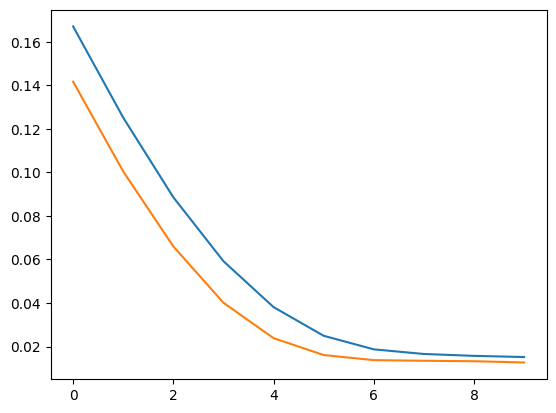

In [52]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])